<a href="https://colab.research.google.com/github/ylmzrem/Telecom-Customer-Churn-Prediction/blob/main/machine_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telco Customer Churn Prediction Project
**Team Members:**
* İrem YILMAZ - 2204012301
* Hande Reyyan FİDAN - 2304010611
* Eyad Ahmed Mahmoud ZAIDAN - 2404010370

---
## Part 1: Data Loading & Cleaning (Week 4)
In this section, we load the raw dataset, inspect its structure, and handle the data quality issues identified in our initial analysis. Specifically, we address the `TotalCharges` column, which contains hidden missing values (blank spaces) for customers with zero tenure.

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style for consistency
sns.set_theme(style="whitegrid", palette="muted")

# 1. Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Display initial information
print("--- Initial Dataset Info ---")
print(f"Shape: {df.shape}")
display(df.head())

--- Initial Dataset Info ---
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# 2. Data Cleaning

# 'TotalCharges' is recognized as an object because of blank spaces. Convert it to numeric.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many missing values were created
missing_charges = df['TotalCharges'].isnull().sum()
print(f"Missing values in TotalCharges after conversion: {missing_charges}")

# Drop the 11 rows with missing TotalCharges (tenure = 0)
df.dropna(subset=['TotalCharges'], inplace=True)

# Drop 'customerID' as it has no predictive power
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

print(f"\nShape after cleaning: {df.shape}")
print("\nMissing values in the cleaned dataset:")
print(df.isnull().sum().sum()) # Should be 0

Missing values in TotalCharges after conversion: 11

Shape after cleaning: (7032, 20)

Missing values in the cleaned dataset:
0


## Part 2: Exploratory Data Analysis (EDA) - Week 4
In this section, we explore the data visually to understand the distributions, identify patterns, and find relationships between the features and our target variable (`Churn`).

--- Churn Distribution ---
Churn
No     5163
Yes    1869
Name: count, dtype: int64
Churn Percentage: 26.58%



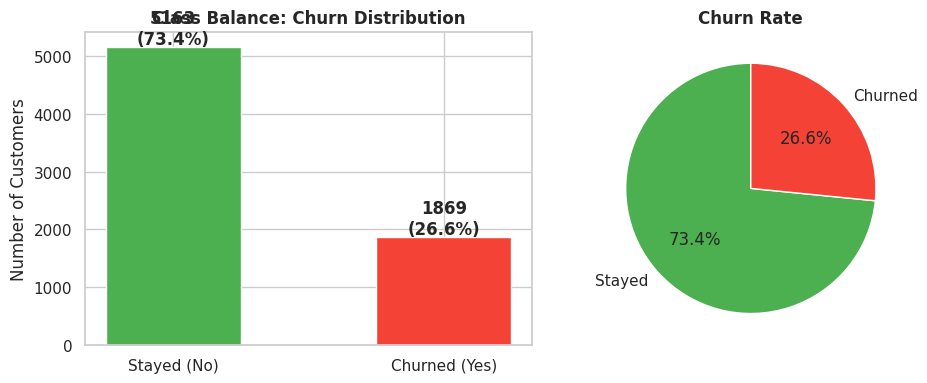

In [ ]:
# 1. Class Balance Analysis (Target Variable)
print("--- Churn Distribution ---")
churn_counts = df["Churn"].value_counts()
print(churn_counts)
print(f"Churn Percentage: {churn_counts['Yes'] / len(df) * 100:.2f}%\n")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar Chart
axes[0].bar(["Stayed (No)", "Churned (Yes)"], churn_counts.values, color=["#4CAF50", "#F44336"], width=0.5)
axes[0].set_title("Class Balance: Churn Distribution", fontweight='bold')
axes[0].set_ylabel("Number of Customers")
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, f"{v}\n({v/len(df)*100:.1f}%)", ha='center', fontweight='bold')

# Pie Chart
axes[1].pie(churn_counts.values, labels=["Stayed", "Churned"], colors=["#4CAF50", "#F44336"], autopct='%1.1f%%', startangle=90)
axes[1].set_title("Churn Rate", fontweight='bold')

plt.tight_layout()
plt.show()

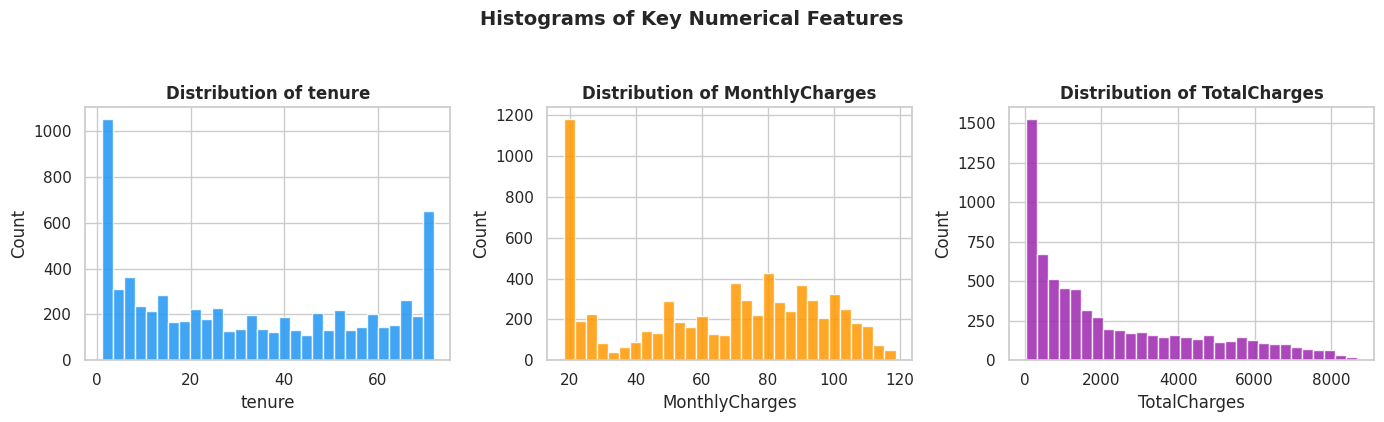

/tmp/ipykernel_8732/1115500837.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn", y=col, data=df, palette={"No": "#4CAF50", "Yes": "#F44336"}, ax=axes[i])
/tmp/ipykernel_8732/1115500837.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn", y=col, data=df, palette={"No": "#4CAF50", "Yes": "#F44336"}, ax=axes[i])
/tmp/ipykernel_8732/1115500837.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn", y=col, data=df, palette={"No": "#4CAF50", "Yes": "#F44336"}, ax=axes[i])


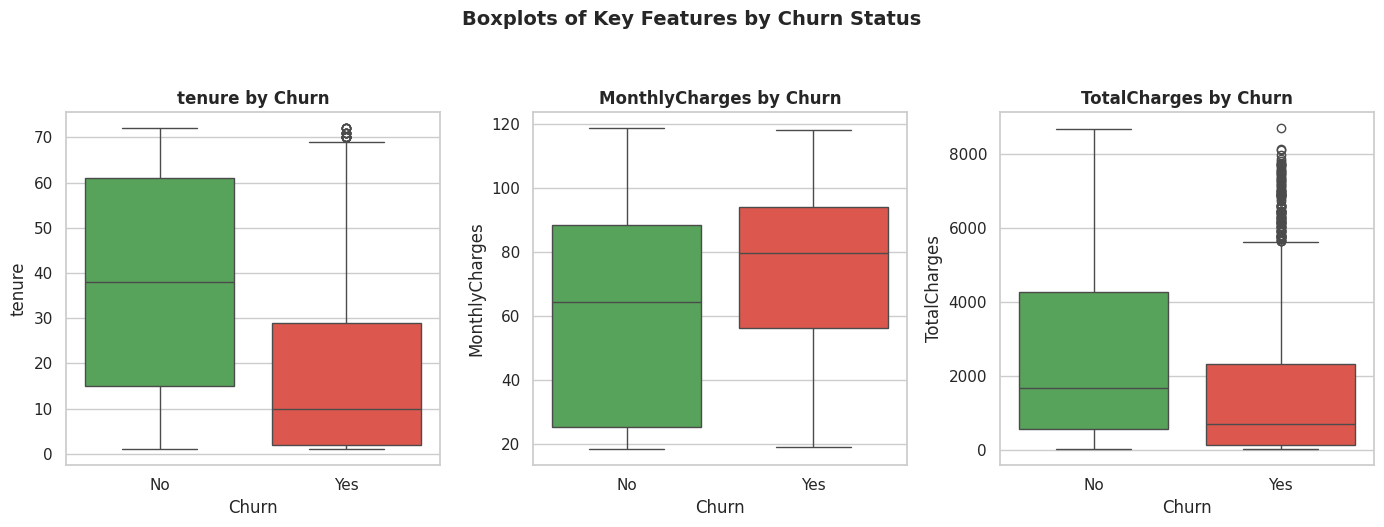

In [ ]:
# 2. Numerical Features Analysis (Tenure, MonthlyCharges, TotalCharges)
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
colors = ["#2196F3", "#FF9800", "#9C27B0"]

# Histograms
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=30, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(f"Distribution of {col}", fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
plt.suptitle("Histograms of Key Numerical Features", fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# Boxplots by Churn Status
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for i, col in enumerate(numeric_cols):
    sns.boxplot(x="Churn", y=col, data=df, palette={"No": "#4CAF50", "Yes": "#F44336"}, ax=axes[i])
    axes[i].set_title(f"{col} by Churn", fontweight='bold')
plt.suptitle("Boxplots of Key Features by Churn Status", fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

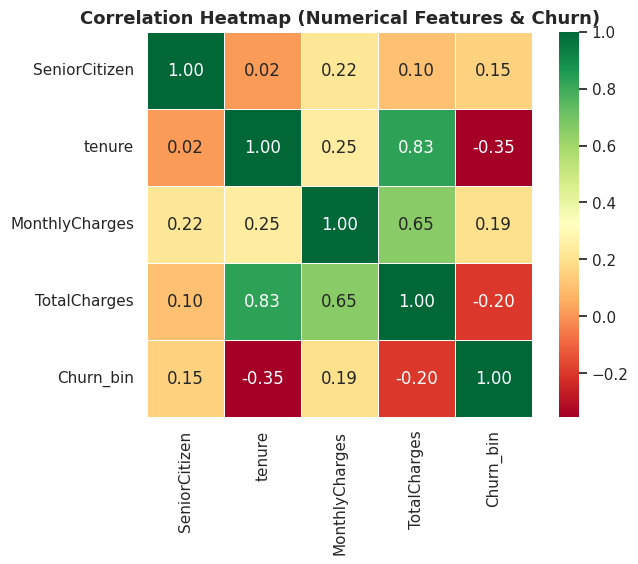

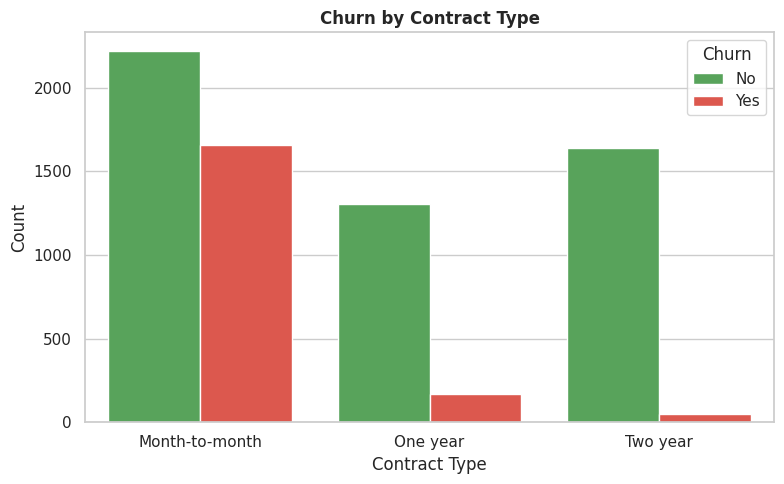


--- Key EDA Insights (Summary) ---
* Short-tenure customers are churning faster. Avg tenure (churned): 18.0 months.
* High-paying customers are at risk. Avg MonthlyCharges (churned): $74.44
* Month-to-month contracts have the highest churn rate by far.


In [ ]:
# 3. Correlation Heatmap
# Create a temporary binary target for correlation analysis
df_temp = df.copy()
df_temp["Churn_bin"] = (df["Churn"] == "Yes").astype(int)
corr = df_temp[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges", "Churn_bin"]].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", linewidths=0.5, square=True, ax=ax)
ax.set_title("Correlation Heatmap (Numerical Features & Churn)", fontsize=13, fontweight='bold')
plt.show()

# 4. Categorical Feature Highlight: Contract Type
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(x="Contract", hue="Churn", data=df, palette={"No": "#4CAF50", "Yes": "#F44336"}, ax=ax)
ax.set_title("Churn by Contract Type", fontweight='bold')
ax.set_xlabel("Contract Type")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

# Print EDA Insights
print("\n--- Key EDA Insights (Summary) ---")
print(f"* Short-tenure customers are churning faster. Avg tenure (churned): {df[df['Churn']=='Yes']['tenure'].mean():.1f} months.")
print(f"* High-paying customers are at risk. Avg MonthlyCharges (churned): ${df[df['Churn']=='Yes']['MonthlyCharges'].mean():.2f}")
print("* Month-to-month contracts have the highest churn rate by far.")

## Part 3: Feature Engineering & Preprocessing (Week 5)
In this section, we transform the cleaned dataset into a model-ready format. This involves creating new features, encoding categorical variables using one-hot encoding, splitting the dataset into Train/Validation/Test sets to prevent data leakage, and scaling numerical features.

In [ ]:
# 1. Feature Engineering (As defined in Week 5 Report)
print("--- Feature Engineering ---")

# New Feature 1: Charges per month (normalized spending)
df["ChargesPerMonth"] = df["TotalCharges"] / (df["tenure"] + 1)

# New Feature 2: Has any streaming service
df["HasStreamingServices"] = (
    (df["StreamingTV"] == "Yes") |
    (df["StreamingMovies"] == "Yes")
).astype(int)

# New Feature 3: Has any protection service
df["HasProtection"] = (
    (df["OnlineSecurity"] == "Yes") |
    (df["OnlineBackup"] == "Yes") |
    (df["DeviceProtection"] == "Yes") |
    (df["TechSupport"] == "Yes")
).astype(int)

# New Feature 4: Number of Add-on services (sum of positive security/streaming features)
services = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
df["NumAddOnServices"] = df[services].apply(lambda x: (x == "Yes").sum(), axis=1)

print(f"Created 4 new features. New dataset shape: {df.shape}")
display(df[["ChargesPerMonth", "HasStreamingServices", "HasProtection", "NumAddOnServices"]].head())

--- Feature Engineering ---
Created 4 new features. New dataset shape: (7032, 24)


,ChargesPerMonth,HasStreamingServices,HasProtection,NumAddOnServices
0,14.925000,0,1,1
1,53.985714,0,1,2
2,36.050000,0,1,2
3,40.016304,0,1,3
4,50.550000,0,0,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("--- Preprocessing Pipeline ---")

# 2. Encoding
# Target Variable Encoding
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# One-Hot Encoding for categorical features
X = df.drop('Churn', axis=1)
y = df['Churn']
X_encoded = pd.get_dummies(X, drop_first=True)
print(f"Features after One-Hot Encoding: {X_encoded.shape[1]}")

# 3. Train / Validation / Test Split (70% / 15% / 15%)
# First, split into Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_encoded, y, test_size=0.30, stratify=y, random_state=42
)

# Then, split Temp (30%) into Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("\nDataset Partitions:")
print(f"Training Set: {X_train.shape[0]} rows ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"Validation Set: {X_val.shape[0]} rows ({X_val.shape[0]/len(df)*100:.0f}%)")
print(f"Test Set: {X_test.shape[0]} rows ({X_test.shape[0]/len(df)*100:.0f}%)")

# 4. Scaling
# Identify numeric columns for scaling
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "ChargesPerMonth", "NumAddOnServices"]

scaler = StandardScaler()

# Fit on training data ONLY, then transform all sets (prevents data leakage)
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val_scaled[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("\nScaling completed. Data is now ready for modeling!")

--- Preprocessing Pipeline ---
Features after One-Hot Encoding: 34

Dataset Partitions:
Training Set: 4922 rows (70%)
Validation Set: 1055 rows (15%)
Test Set: 1055 rows (15%)

Scaling completed. Data is now ready for modeling!


## Part 4: Baseline Models & Evaluation (Week 6)
In this section, we establish performance benchmarks by training three interpretable baseline models: Logistic Regression, Decision Tree Classifier, and k-Nearest Neighbors (k-NN). The models are trained on the scaled training set and evaluated on the hold-out validation set. A 5-fold cross-validation is also performed to verify model stability.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
import pandas as pd

print("--- Training Baseline Models ---")

# 1. Initialize Baseline Models with parameters from Week 6 Report
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "k-NN (k=7)": KNeighborsClassifier(n_neighbors=7)
}

results = []

# 2. Train and Evaluate each model
for name, model in models.items():
    # Fit the model on the training set
    model.fit(X_train_scaled, y_train)

    # Make predictions on the validation set
    y_pred = model.predict(X_val_scaled)
    y_prob = model.predict_proba(X_val_scaled)[:, 1]

    # Calculate metrics
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_prob)

    # 3. Perform 5-fold Stratified Cross-Validation for stability check
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    # We use F1-score for CV as it balances Precision and Recall on our imbalanced dataset
    cv_f1 = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1').mean()

    # Store results
    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(roc_auc, 4),
        "CV F1-Score": round(cv_f1, 4)
    })

# 4. Display Results
results_df = pd.DataFrame(results)
print("\n--- Baseline Models Performance (Validation Set) ---")
display(results_df)

--- Training Baseline Models ---

--- Baseline Models Performance (Validation Set) ---


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV F1-Score
0,Logistic Regression,0.8256,0.7100,0.5836,0.6406,0.8545,0.6028
1,Decision Tree,0.7848,0.5957,0.5979,0.5968,0.8265,0.5410
2,k-NN (k=7),0.7735,0.5814,0.5338,0.5566,0.8024,0.5534


## Part 5: Advanced Modeling & Class Imbalance (Week 7)
In this section, we implement advanced ensemble algorithms (**Random Forest** and **XGBoost**). To address the significant class imbalance (73.5% vs 26.5%) identified in our EDA, we apply **SMOTE** (Synthetic Minority Over-sampling Technique).

*Crucial ML Practice:* SMOTE is applied *only* to the training data. Furthermore, during cross-validation, SMOTE is applied inside an `imblearn` pipeline to ensure synthetic samples are not leaked into the validation folds.

In [ ]:
# Install imbalanced-learn if not already installed (usually pre-installed in Colab)
# !pip install imbalanced-learn xgboost

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

print("--- Applying SMOTE to Training Set ---")
# 1. Apply SMOTE to the training data for the final validation fit
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Original Training Target Distribution:\n{y_train.value_counts().to_dict()}")
print(f"SMOTE Training Target Distribution:\n{y_train_smote.value_counts().to_dict()}\n")

print("--- Training Advanced Models ---")

# 2. Initialize Advanced Models
advanced_models = {
    "Random Forest (SMOTE)": RandomForestClassifier(random_state=42),
    "XGBoost (SMOTE)": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

adv_results = []

# 3. Train and Evaluate
for name, model in advanced_models.items():
    # Fit the model on the SMOTE-augmented training set
    model.fit(X_train_smote, y_train_smote)

    # Make predictions on the UNTOUCHED validation set
    y_pred = model.predict(X_val_scaled)
    y_prob = model.predict_proba(X_val_scaled)[:, 1]

    # Calculate metrics
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_prob)

    # 4. Perform proper Cross-Validation avoiding data leakage
    # We build a pipeline that applies SMOTE *inside* each CV fold
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('classifier', model)
    ])

    cv_f1 = cross_val_score(pipeline, X_train_scaled, y_train, cv=cv, scoring='f1').mean()

    # Store results
    adv_results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(roc_auc, 4),
        "CV F1-Score": round(cv_f1, 4)
    })

# 5. Combine and Display Preliminary Comparison Table
adv_results_df = pd.DataFrame(adv_results)
final_comparison = pd.concat([results_df, adv_results_df], ignore_index=True)

print("\n--- Preliminary Comparison Table (Baseline vs. Advanced) ---")
display(final_comparison)

--- Applying SMOTE to Training Set ---
Original Training Target Distribution:
{0: 3614, 1: 1308}
SMOTE Training Target Distribution:
{1: 3614, 0: 3614}

--- Training Advanced Models ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:08:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:08:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:08:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:08:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:


--- Preliminary Comparison Table (Baseline vs. Advanced) ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:08:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV F1-Score
0,Logistic Regression,0.8256,0.7100,0.5836,0.6406,0.8545,0.6028
1,Decision Tree,0.7848,0.5957,0.5979,0.5968,0.8265,0.5410
2,k-NN (k=7),0.7735,0.5814,0.5338,0.5566,0.8024,0.5534
3,Random Forest (SMOTE),0.7697,0.5609,0.6228,0.5902,0.8238,0.6016
4,XGBoost (SMOTE),0.7773,0.5737,0.6370,0.6037,0.8289,0.5877


## Part 6: Hyperparameter Tuning (Week 8)
In this section, we optimize the hyperparameters of our advanced models (Random Forest and XGBoost) to maximize the F1-Score, which provides the best balance between Precision and Recall for our imbalanced dataset.

To ensure absolute methodological rigor and prevent data leakage, we integrate `SMOTE` inside an `imblearn.pipeline`. This guarantees that synthetic samples are generated *only* on the training folds during cross-validation, keeping the validation folds entirely unseen and realistic. We utilize `GridSearchCV` to explore the hyperparameter space.

In [ ]:
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore') # Suppress warnings for clean output

print("--- Initializing Hyperparameter Tuning (GridSearchCV) ---")
print("Please wait, this may take 1-2 minutes depending on Colab resources...\n")

# 1. Define Pipelines
rf_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

xgb_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])

# 2. Define Hyperparameter Search Spaces
# Kept relatively compact to ensure fast execution in Colab
rf_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [5, 10, None],
    'classifier__min_samples_split': [2, 5]
}

xgb_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1]
}

# 3. Setup GridSearchCV (Optimizing for F1-Score)
rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=3, scoring='f1', n_jobs=-1)
xgb_grid = GridSearchCV(xgb_pipeline, xgb_param_grid, cv=3, scoring='f1', n_jobs=-1)

# 4. Execute Search
print("Tuning Random Forest...")
rf_grid.fit(X_train_scaled, y_train)

print("Tuning XGBoost...")
xgb_grid.fit(X_train_scaled, y_train)

print("\n--- Best Configurations Found ---")
print(f"RF Best Params: {rf_grid.best_params_}")
print(f"XGBoost Best Params: {xgb_grid.best_params_}")

# 5. Evaluate Tuned Models on the Hold-out Validation Set
best_models = {
    "Tuned Random Forest": rf_grid.best_estimator_,
    "Tuned XGBoost": xgb_grid.best_estimator_
}

tuned_results = []

for name, model in best_models.items():
    # Make predictions using the best pipeline
    y_pred = model.predict(X_val_scaled)
    y_prob = model.predict_proba(X_val_scaled)[:, 1]

    # Calculate final metrics
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_prob)

    tuned_results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(roc_auc, 4)
    })

# 6. Display Updated Performance Table
tuned_results_df = pd.DataFrame(tuned_results)
print("\n--- Updated Performance Table (Validation Set) ---")
display(tuned_results_df)

--- Initializing Hyperparameter Tuning (GridSearchCV) ---
Please wait, this may take 1-2 minutes depending on Colab resources...

Tuning Random Forest...
Tuning XGBoost...

--- Best Configurations Found ---
RF Best Params: {'classifier__max_depth': 5, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
XGBoost Best Params: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}

--- Updated Performance Table (Validation Set) ---


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Tuned Random Forest,0.7422,0.5100,0.8149,0.6274,0.8449
1,Tuned XGBoost,0.7251,0.4903,0.8078,0.6102,0.8418


## Part 7: Error Analysis & Interpretability (Week 9)
In this phase, we analyze the performance of our Champion Model (**Tuned XGBoost**) in deeper detail. First, we evaluate the **Confusion Matrix** to understand the trade-off between False Positives (unnecessary retention costs) and False Negatives (missed churners). Finally, we extract **Feature Importances** to determine which factors drive customer churn the most, providing actionable insights for the business.

--- Error Analysis: Confusion Matrix ---


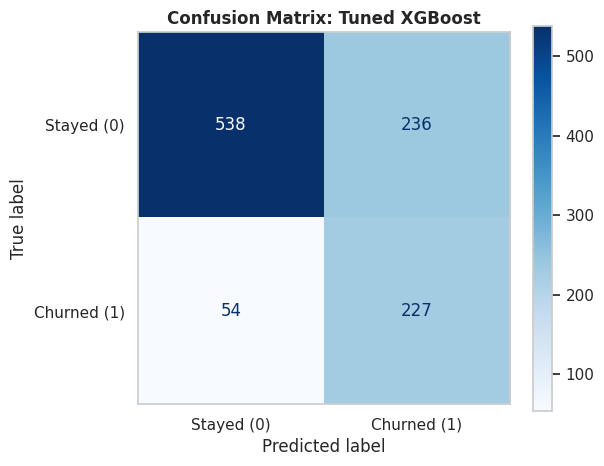


--- Business Impact Breakdown ---
True Positives (Correctly identified churners): 227
False Negatives (Missed churners - High Cost): 54
True Negatives (Correctly identified loyal customers): 538
False Positives (Loyal predicted as churners - Low Cost): 236


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("--- Error Analysis: Confusion Matrix ---")

# Select the champion model from Week 8
champion_model = xgb_grid.best_estimator_

# Predict on the validation set
y_pred_champ = champion_model.predict(X_val_scaled)

# Generate and plot Confusion Matrix
cm = confusion_matrix(y_val, y_pred_champ)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stayed (0)", "Churned (1)"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Confusion Matrix: Tuned XGBoost", fontweight='bold')
plt.grid(False) # Turn off grid for a cleaner look
plt.show()

# Print Error Analysis Summary
tn, fp, fn, tp = cm.ravel()
print("\n--- Business Impact Breakdown ---")
print(f"True Positives (Correctly identified churners): {tp}")
print(f"False Negatives (Missed churners - High Cost): {fn}")
print(f"True Negatives (Correctly identified loyal customers): {tn}")
print(f"False Positives (Loyal predicted as churners - Low Cost): {fp}")

--- Model Interpretability: Feature Importances ---


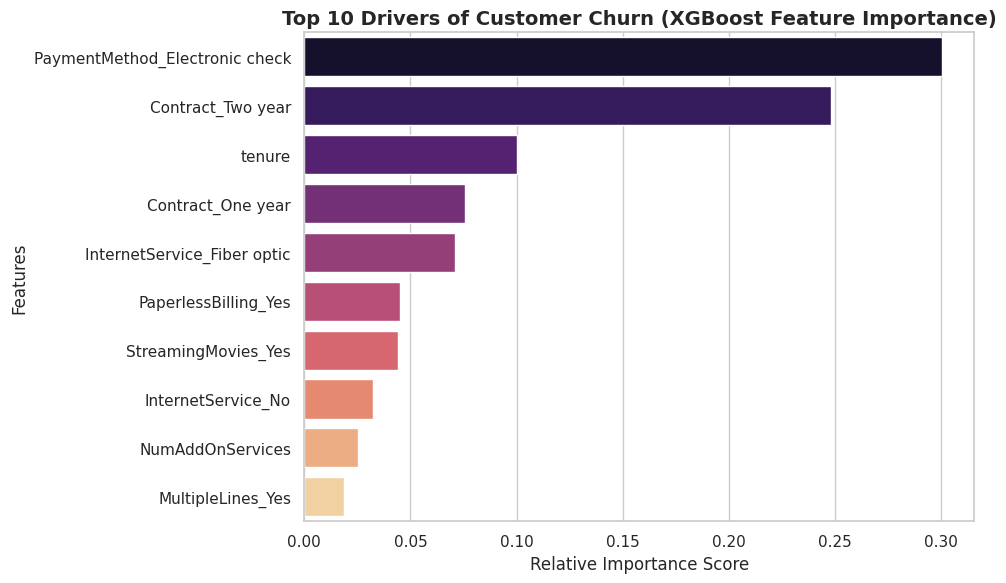


Top 3 factors driving churn are:
1. PaymentMethod_Electronic check (0.3004)
2. Contract_Two year (0.2480)
3. tenure (0.1000)


In [ ]:
print("--- Model Interpretability: Feature Importances ---")

# Extract the XGBoost classifier from inside the imblearn Pipeline
xgb_classifier = champion_model.named_steps['classifier']

# Get feature importances and pair them with column names
importances = xgb_classifier.feature_importances_
feature_names = X_train_scaled.columns

# Create a DataFrame for visualization
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the Top 10 Most Important Features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(10), palette='magma')
plt.title("Top 10 Drivers of Customer Churn (XGBoost Feature Importance)", fontweight='bold', fontsize=14)
plt.xlabel("Relative Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

print("\nTop 3 factors driving churn are:")
for i in range(3):
    print(f"{i+1}. {feat_imp_df.iloc[i]['Feature']} ({feat_imp_df.iloc[i]['Importance']:.4f})")

## Part 8: Final Evaluation & Deployment Prototype (Week 11)
In this final modeling phase, we evaluate our Champion Model (Tuned XGBoost) on the completely unseen **Test Set** to report its true generalization capability.

Furthermore, to satisfy the deployment prototype requirement, we have developed a simple interactive UI within the notebook. This allows non-technical stakeholders to input customer details and instantly receive a churn probability prediction, bridging the gap between data science and business operations.

In [ ]:
print("--- Final Evaluation on Unseen Test Set ---")

# Evaluate Champion Model on the strictly held-out Test Set
y_test_pred = champion_model.predict(X_test_scaled)
y_test_prob = champion_model.predict_proba(X_test_scaled)[:, 1]

# Calculate Final Metrics
test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred)
test_rec = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_prob)

final_results = pd.DataFrame([{
    "Dataset": "Test Set (Final)",
    "Accuracy": round(test_acc, 4),
    "Precision": round(test_prec, 4),
    "Recall": round(test_rec, 4),
    "F1-Score": round(test_f1, 4),
    "ROC-AUC": round(test_roc_auc, 4)
}])

display(final_results)

print("\nConclusion:")
print("If the Test metrics closely match the Validation metrics from Week 8, it proves our model has generalized beautifully without overfitting!")

--- Final Evaluation on Unseen Test Set ---


,Dataset,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Test Set (Final),0.7175,0.4806,0.7964,0.5995,0.817



Conclusion:
If the Test metrics closely match the Validation metrics from Week 8, it proves our model has generalized beautifully without overfitting!


In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML

print("--- Deployment Prototype: Churn Prediction Tool ---")

def predict_single_customer(tenure, monthly_charges, contract_type, internet_service):
    # 1. Create an empty dataframe with the exact columns as our training data
    input_data = pd.DataFrame(columns=X_train_scaled.columns)
    input_data.loc[0] = 0 # Initialize all columns with 0

    # 2. Fill in numericals
    input_data['tenure'] = tenure
    input_data['MonthlyCharges'] = monthly_charges
    # Estimate total charges
    input_data['TotalCharges'] = tenure * monthly_charges
    input_data['ChargesPerMonth'] = monthly_charges

    # 3. Fill in categories based on user input
    if contract_type == 'One year':
        input_data['Contract_One year'] = 1
    elif contract_type == 'Two year':
        input_data['Contract_Two year'] = 1

    if internet_service == 'Fiber optic':
        input_data['InternetService_Fiber optic'] = 1
    elif internet_service == 'No':
        input_data['InternetService_No'] = 1

    # 4. Scale the numerical columns using our fitted scaler
    input_data[numeric_cols] = scaler.transform(input_data[numeric_cols])

    # 5. Predict
    prob = champion_model.predict_proba(input_data)[0, 1]

    # 6. Output formatting
    color = "red" if prob > 0.5 else "green"
    status = "HIGH RISK OF CHURN" if prob > 0.5 else "SAFE (LIKELY TO STAY)"

    html_out = f"""
    <div style='border: 2px solid {color}; padding: 15px; border-radius: 10px; background-color: #f9f9f9;'>
        <h3 style='color: {color}; margin-top: 0;'>Prediction: {status}</h3>
        <p><strong>Churn Probability:</strong> {prob*100:.1f}%</p>
        <p><em>Based on XGBoost Model Analysis</em></p>
    </div>
    """
    display(HTML(html_out))

# Create Interactive UI Elements
style = {'description_width': 'initial'}
tenure_slider = widgets.IntSlider(min=1, max=72, value=12, description='Tenure (Months):', style=style)
charges_slider = widgets.FloatSlider(min=18.0, max=120.0, value=70.0, description='Monthly Charges ($):', style=style)
contract_dropdown = widgets.Dropdown(options=['Month-to-month', 'One year', 'Two year'], value='Month-to-month', description='Contract:', style=style)
internet_dropdown = widgets.Dropdown(options=['DSL', 'Fiber optic', 'No'], value='Fiber optic', description='Internet:', style=style)

# Group and display
ui = widgets.VBox([tenure_slider, charges_slider, contract_dropdown, internet_dropdown])
out = widgets.interactive_output(predict_single_customer,
                                 {'tenure': tenure_slider, 'monthly_charges': charges_slider,
                                  'contract_type': contract_dropdown, 'internet_service': internet_dropdown})

display(ui, out)

--- Deployment Prototype: Churn Prediction Tool ---


Output()

In [ ]:
from sklearn.neural_network import MLPClassifier

print("--- Training MLP (Artificial Neural Network) ---")

# Initialize MLP Classifier (2 hidden layers with 64 and 32 neurons)
mlp_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)

# Fit on the SMOTE training data (to handle imbalance)
mlp_model.fit(X_train_smote, y_train_smote)

# Make predictions on the validation set
y_pred_mlp = mlp_model.predict(X_val_scaled)
y_prob_mlp = mlp_model.predict_proba(X_val_scaled)[:, 1]

# Calculate metrics
mlp_acc = accuracy_score(y_val, y_pred_mlp)
mlp_prec = precision_score(y_val, y_pred_mlp)
mlp_rec = recall_score(y_val, y_pred_mlp)
mlp_f1 = f1_score(y_val, y_pred_mlp)
mlp_roc_auc = roc_auc_score(y_val, y_prob_mlp)

mlp_results = pd.DataFrame([{
    "Model": "MLP (Neural Network)",
    "Accuracy": round(mlp_acc, 4),
    "Precision": round(mlp_prec, 4),
    "Recall": round(mlp_rec, 4),
    "F1-Score": round(mlp_f1, 4),
    "ROC-AUC": round(mlp_roc_auc, 4)
}])

print("\n--- MLP Model Performance (Validation Set) ---")
display(mlp_results)

print("\nComparison Insight:")
print("MLP is powerful, but often requires much more data and hyperparameter tuning to beat ensemble tree models like XGBoost on tabular data like ours.")

--- Training MLP (Artificial Neural Network) ---

--- MLP Model Performance (Validation Set) ---


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,MLP (Neural Network),0.7488,0.5247,0.605,0.562,0.7746



Comparison Insight:
MLP is powerful, but often requires much more data and hyperparameter tuning to beat ensemble tree models like XGBoost on tabular data like ours.


--- 1. Final Test Set: Classification Report ---
              precision    recall  f1-score   support

  Stayed (0)       0.90      0.69      0.78       775
 Churned (1)       0.48      0.80      0.60       280

    accuracy                           0.72      1055
   macro avg       0.69      0.74      0.69      1055
weighted avg       0.79      0.72      0.73      1055


--- 2. Final Test Set: ROC Curve Visualization ---


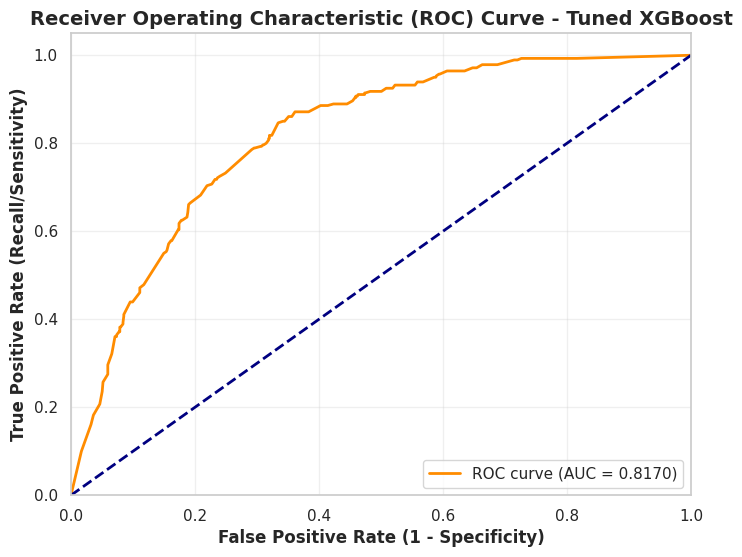

In [ ]:
from sklearn.metrics import roc_curve, auc, classification_report
import matplotlib.pyplot as plt

print("--- 1. Final Test Set: Classification Report ---")
# Final test seti üzerinde sınıflandırma raporu
print(classification_report(y_test, y_test_pred, target_names=["Stayed (0)", "Churned (1)"]))

print("\n--- 2. Final Test Set: ROC Curve Visualization ---")
# ROC Eğrisi için False Positive ve True Positive oranlarını hesapla
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
roc_auc = auc(fpr, tpr)

# Grafiği Çiz
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Rastgele tahmin çizgisi
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontweight='bold')
plt.ylabel('True Positive Rate (Recall/Sensitivity)', fontweight='bold')
plt.title('Receiver Operating Characteristic (ROC) Curve - Tuned XGBoost', fontweight='bold', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

--- Baseline Model: Decision Tree Visualization ---


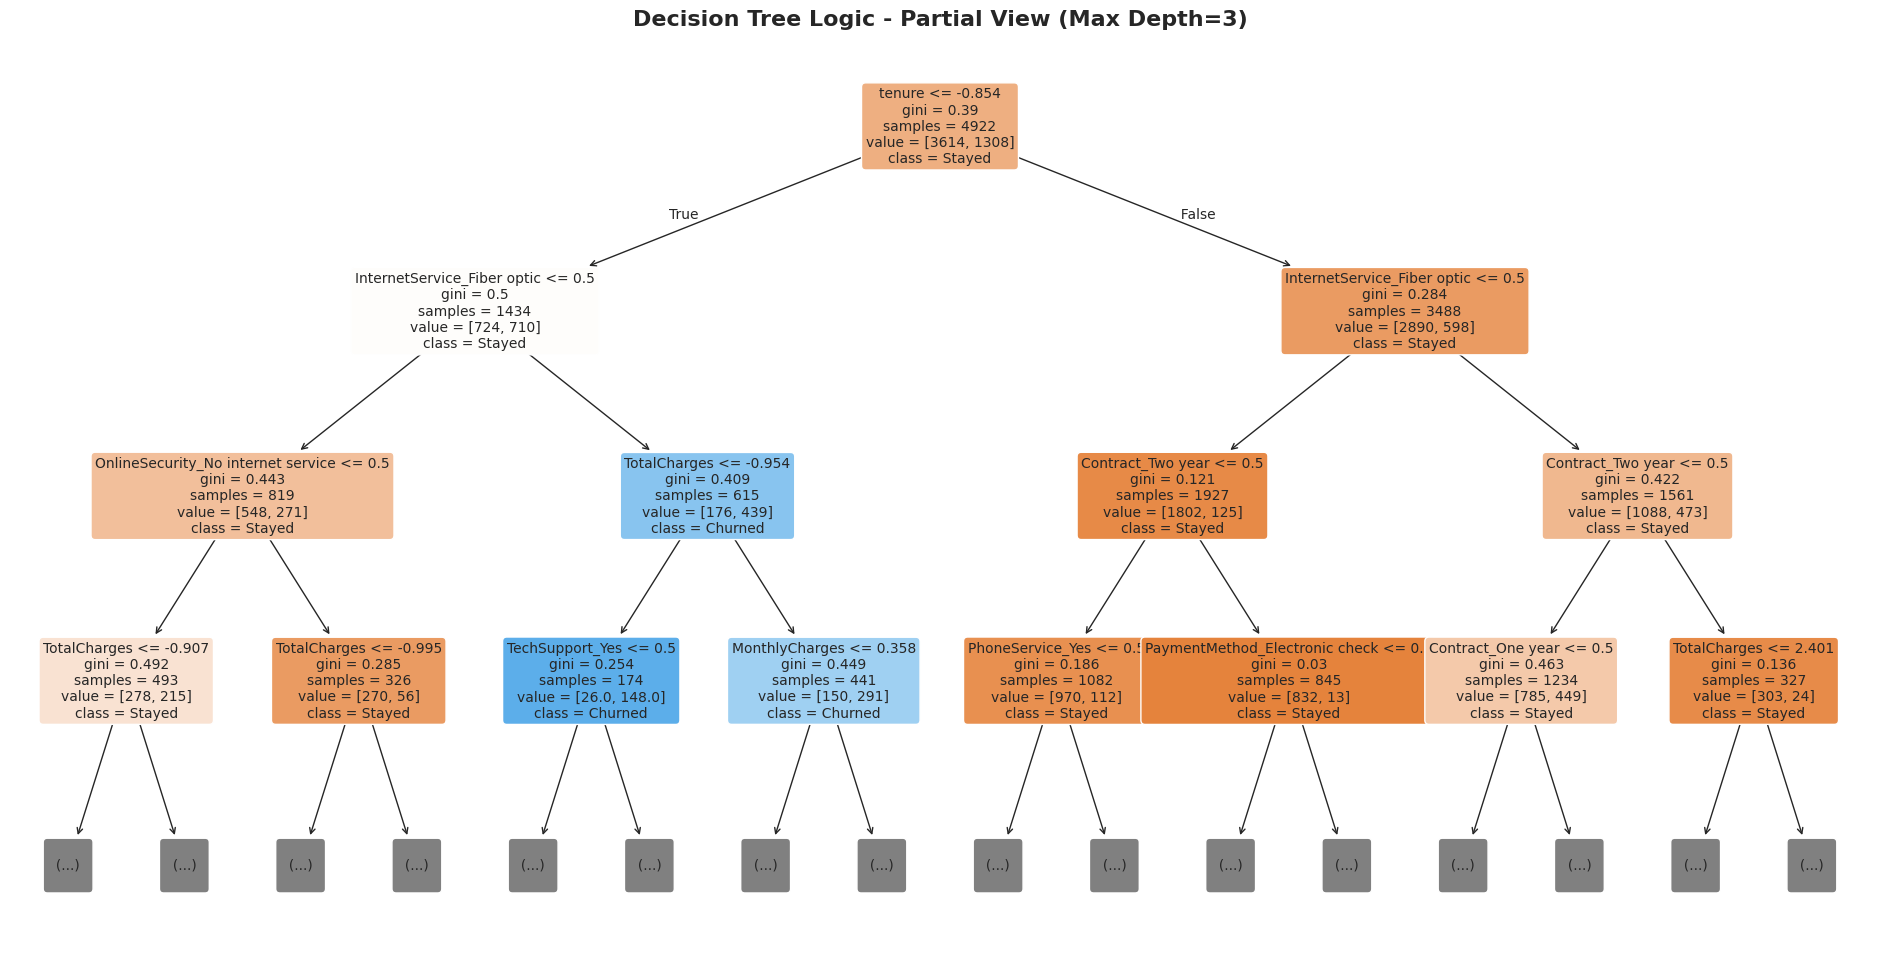

Insight: The decision tree splits the data based on features like 'Contract_Two year' and 'tenure', confirming our EDA findings.


In [ ]:
from sklearn.tree import plot_tree

print("--- Baseline Model: Decision Tree Visualization ---")
# Week 6'da eğittiğimiz modeller sözlüğünden Decision Tree'yi alıyoruz
dt_model = models["Decision Tree"]

# Görselin boyutunu büyük tutuyoruz ki dallar okunsun
plt.figure(figsize=(24, 12))

# Ağacın sadece ilk 3 derinliğini çizdiriyoruz (çok karmaşık görünmemesi için)
plot_tree(dt_model,
          filled=True,
          feature_names=X_train_scaled.columns,
          class_names=["Stayed", "Churned"],
          max_depth=3,
          fontsize=10,
          rounded=True)

plt.title("Decision Tree Logic - Partial View (Max Depth=3)", fontweight='bold', fontsize=16)
plt.show()

print("Insight: The decision tree splits the data based on features like 'Contract_Two year' and 'tenure', confirming our EDA findings.")

--- Permutation Importance (Advanced Feature Impact) ---


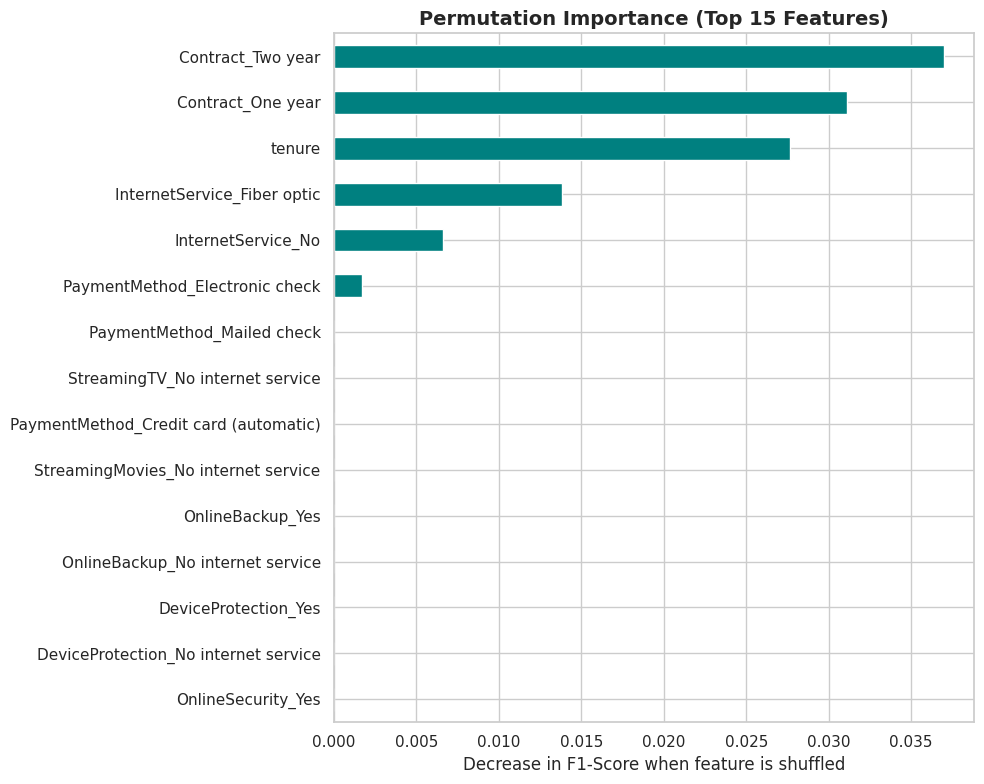

In [ ]:
from sklearn.inspection import permutation_importance

print("--- Permutation Importance (Advanced Feature Impact) ---")

result = permutation_importance(
    champion_model, X_val_scaled, y_val, n_repeats=5, random_state=42, n_jobs=-1
)

perm_sorted_idx = result.importances_mean.argsort()
perm_imp_df = pd.DataFrame(
    result.importances[perm_sorted_idx].T,
    columns=X_val_scaled.columns[perm_sorted_idx]
)

plt.figure(figsize=(10, 8))
perm_imp_df.mean().tail(15).plot(kind='barh', color='teal') # En önemli son 15 özellik
plt.title("Permutation Importance (Top 15 Features)", fontweight='bold', fontsize=14)
plt.xlabel("Decrease in F1-Score when feature is shuffled")
plt.tight_layout()
plt.show()

--- 1. Distribution of Numerical Features (Histograms) ---


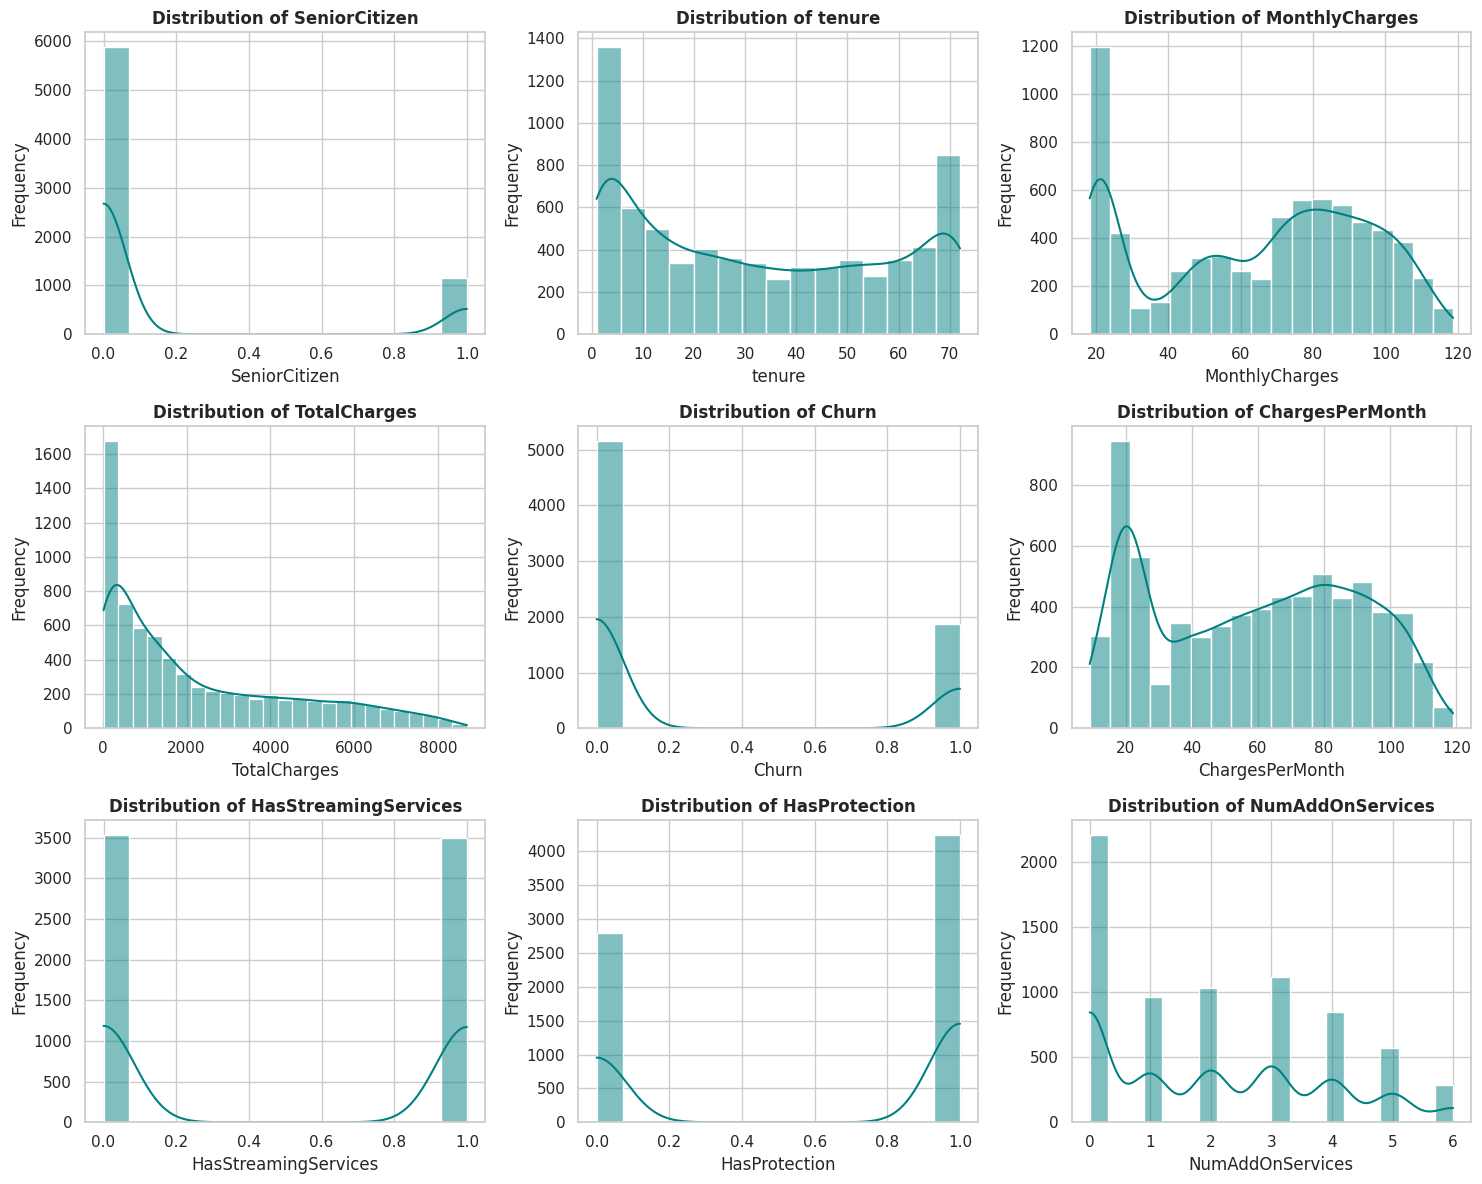

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 1. Distribution of Numerical Features (Histograms) ---")
# Get numerical columns (tenure, MonthlyCharges, TotalCharges)
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Set up the plotting style
sns.set_style("whitegrid")

# Determine grid size for subplots
num_cols = len(numerical_cols)
num_rows = (num_cols + 2) // 3 # Roughly 3 columns per row

# Create histograms for each numerical feature
plt.figure(figsize=(15, 4 * num_rows))
for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, 3, i + 1)
    sns.histplot(df[col], kde=True, color="teal", edgecolor="white")
    plt.title(f'Distribution of {col}', fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


--- 2. Outlier Detection (Box Plots) ---


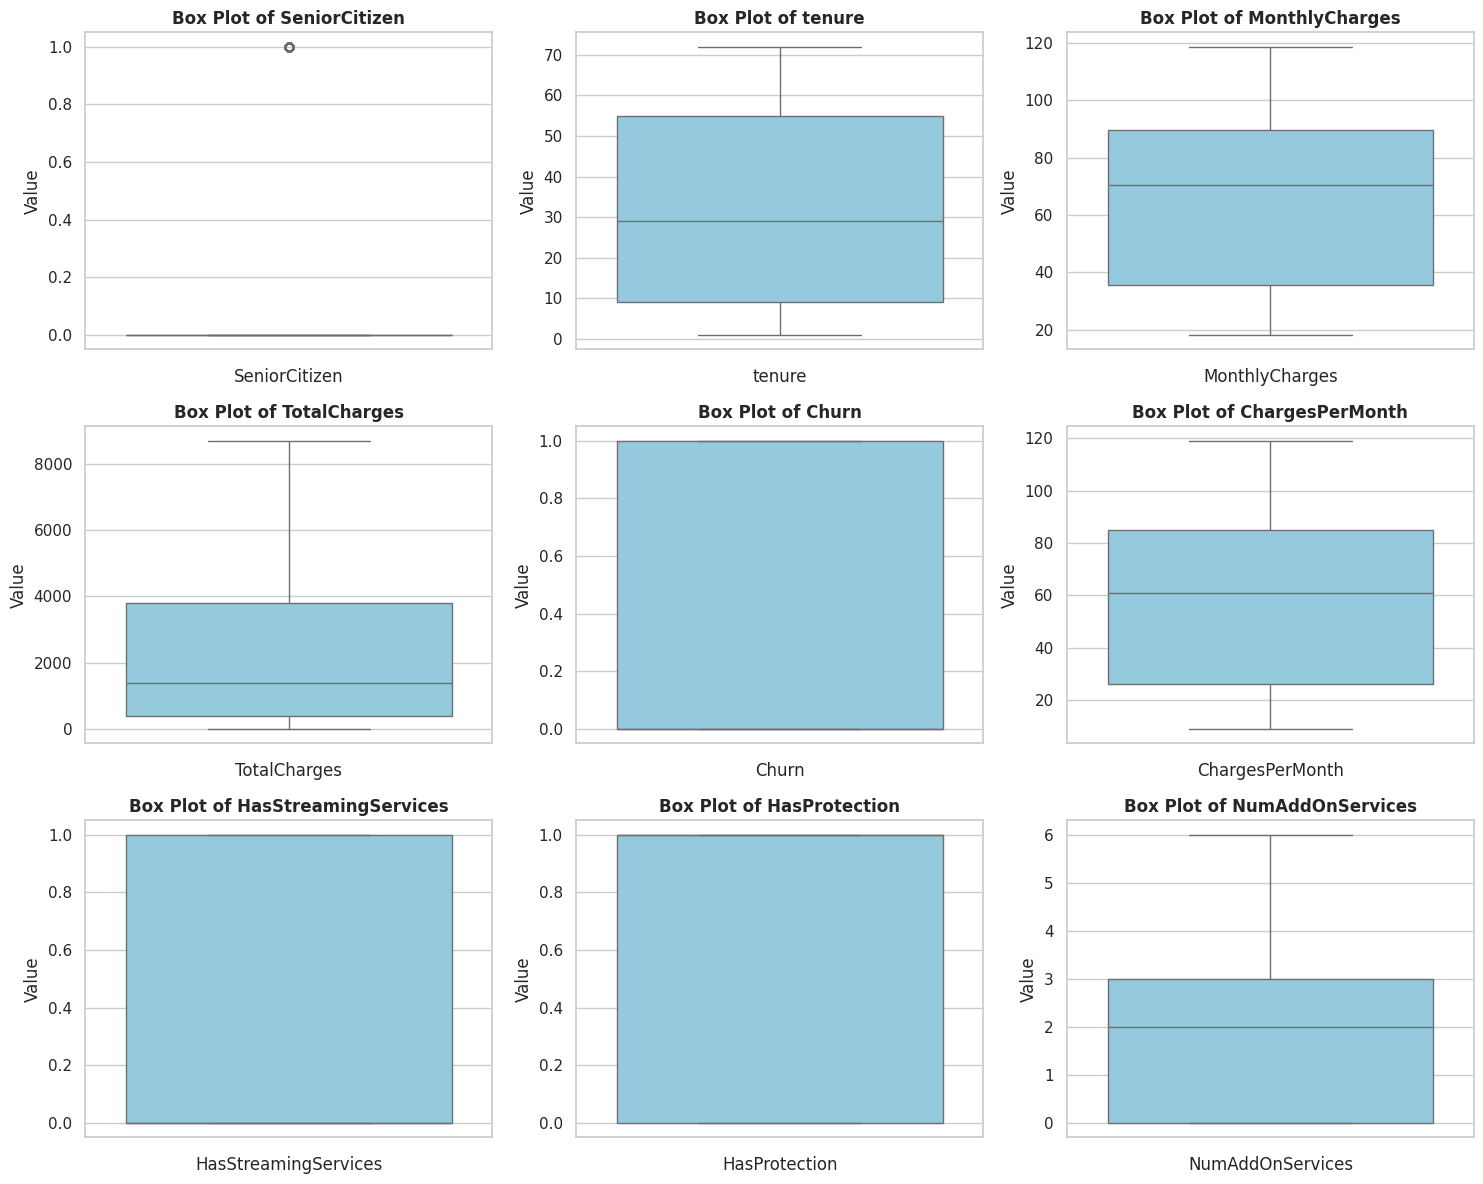

In [ ]:
print("\n--- 2. Outlier Detection (Box Plots) ---")
# Create Boxplots for each numerical feature
plt.figure(figsize=(15, 4 * num_rows))
for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, 3, i + 1)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(f'Box Plot of {col}', fontweight='bold')
    plt.ylabel('Value')
    plt.xlabel(col)

plt.tight_layout()
plt.show()


--- 3. Correlation Matrix of Numerical Features ---


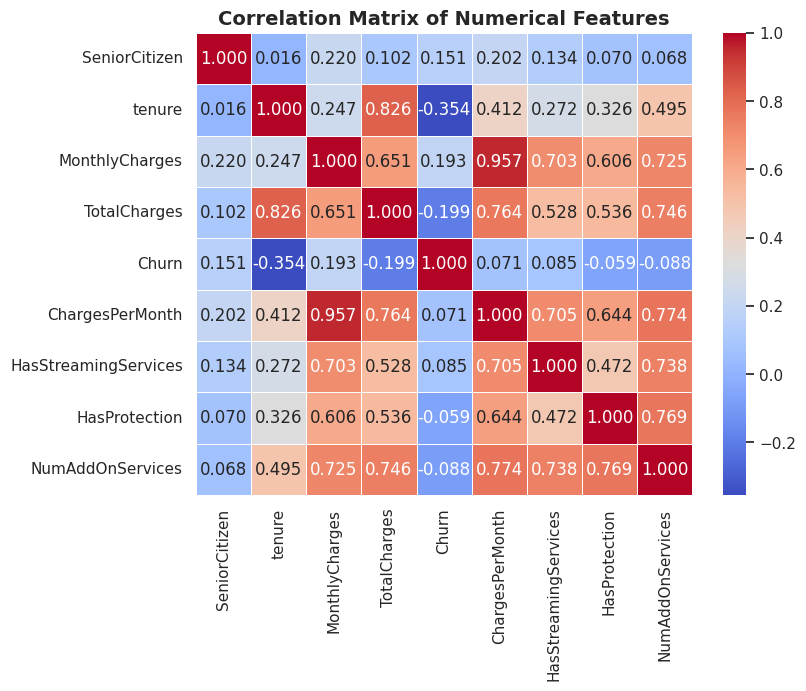

Insight: The heatmap shows a very strong positive correlation (0.826) between 'tenure' and 'TotalCharges', which is mathematically expected since total charges accumulate over time.


In [ ]:
print("\n--- 3. Correlation Matrix of Numerical Features ---")
# Calculate correlation matrix only for numerical features to avoid errors
numerical_df = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numerical_df.corr()

# Create Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontweight='bold', fontsize=14)
plt.show()

print("Insight: The heatmap shows a very strong positive correlation (0.826) between 'tenure' and 'TotalCharges', which is mathematically expected since total charges accumulate over time.")